# 07 Bison Habitat Suitability Index

**Project:** Pine Ridge Bison Habitat Suitability Analysis  
**Partner:** Oglala Lakota College (OLC)/Cubedynamics  
**Author:** Lilly Jones, PhD Daear Consulting, LLC

## What This Notebook Does

This is the synthesis notebook. It combines the five component layers
built in notebooks 02–06 into the Bison Habitat Suitability Index (BHSI),
then labels contiguous high-suitability areas to identify and rank priority restoration units.

**Two outputs:**

1. **BHSI raster** (GeoTIFF) a continuous 0–1 score across the full
   Pine Ridge Reservation. Higher score = better current or restorable
   bison habitat.

2. **Priority restoration units** (GeoPackage + CSV) contiguous
   high-BHSI contiguous patches, ranked by
   composite quality score, with area, water access, soils, and
   land cover summaries.

## Algorithm: Raster-native contiguous patches

Patches use 8-neighbor raster connectivity and a minimum-area filter.
Key parameters (all in `src/constants.py`):
- `MIN_PATCH_ACRES = 500`: minimum viable patch size
- `BHSI_THRESHOLD_PCT = 70`: top N% of scores classified as high-suitability

Review `MIN_PATCH_ACRES` with the OLC bison program before finalizing.


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT/"src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import rasterio
from rasterio.features import shapes
from shapely.geometry import shape

from src.constants import (
    CRS_GEOGRAPHIC, CRS_PROJECTED, TARGET_RES_M,
    BHSI_WEIGHTS, MIN_PATCH_ACRES, BHSI_THRESHOLD_PCT,
    CACHE_DIR, OUTPUTS_DIR, FIGURES_DIR,
)
from src.raster_utils import combine_bhsi_layers
from src.validation import validate_bhsi_layers
from src.patches import label_habitat_patches
from src.provenance import write_bhsi_manifest
from src.sovereignty import print_data_acknowledgment, generate_citations

warnings.filterwarnings("ignore")
%matplotlib inline

TEMPLATE_PATH = CACHE_DIR/"template_30m_albers.tif"
assert TEMPLATE_PATH.exists(), "Run notebook 01 first."
pine_ridge = gpd.read_file(OUTPUTS_DIR/"pine_ridge_boundary.geojson")

# Check which component layers exist
LAYER_PATHS = {
    "vegetation":  OUTPUTS_DIR/"bhsi_vegetation.tif",
    "soils":       OUTPUTS_DIR/"bhsi_soils.tif",
    "topography":  OUTPUTS_DIR/"bhsi_topography.tif",
    "water":       OUTPUTS_DIR/"bhsi_water.tif",
    "climate":     OUTPUTS_DIR/"bhsi_climate.tif",
}

available = {k: v for k, v in LAYER_PATHS.items() if v.exists()}
missing   = [k for k in LAYER_PATHS if k not in available]

print(f"Available layers: {list(available.keys())}")
if missing:
    raise FileNotFoundError(f"Missing required layers: {missing}. Run notebooks 02–06 first.")
if not np.isclose(sum(BHSI_WEIGHTS.values()), 1.0):
    raise ValueError("BHSI weights must sum to 1.0.")
validate_bhsi_layers(available, set(BHSI_WEIGHTS))
print(f"\nBHSI weights: {BHSI_WEIGHTS}")

Available layers: ['vegetation', 'soils', 'topography', 'water', 'climate']

BHSI weights: {'vegetation': 0.3, 'soils': 0.2, 'water': 0.25, 'topography': 0.15, 'climate': 0.1}


In [2]:
# Print the data sovereignty statement at the top of every notebook
print_data_acknowledgment()


PINE RIDGE BISON HABITAT ANALYSIS DATA GOVERNANCE ACKNOWLEDGMENT
This analysis describes land within the Pine Ridge Reservation, home of
the Oglala Lakota Nation. Bison (Pte Oyate) hold deep cultural, spiritual,
and ecological significance for the Oglala Lakota people. This analysis
exists to support Tribal land stewardship, not to define it.

Results should be understood as one input into a land management
conversation, not as a determination of where bison belong.
That determination rests with the Oglala Lakota Nation.

GOVERNANCE FRAMEWORKS:

OCAP®  : The Oglala Lakota Nation has Ownership, Control, Access, and
  Possession of data describing their land and resources. Analysis results
  derived from public federal data about Pine Ridge still carry this
  obligation. Share results with OLC Cubedynamics and the relevant
  Oglala Lakota Nation land management offices before external distribution.
  Reference: https://fnigc.ca/ocap-training/

CARE   : Analysis must deliver Collective B

## Combine Component Layers to create the BHSI

In [3]:
bhsi_path = OUTPUTS_DIR/"bhsi_composite.tif"

bhsi_array = combine_bhsi_layers(
    layer_paths  = available,
    weights      = BHSI_WEIGHTS,
    output_path  = bhsi_path,
)

valid = bhsi_array[~np.isnan(bhsi_array)]
print(f"BHSI composite statistics:")
print(f"  Valid pixels  : {len(valid):,}")
print(f"  Min           : {valid.min():.3f}")
print(f"  Max           : {valid.max():.3f}")
print(f"  Mean          : {valid.mean():.3f}")
print(f"  Median        : {np.median(valid):.3f}")
print(f"  75th pct      : {np.percentile(valid, 75):.3f}")
print(f"  90th pct      : {np.percentile(valid, 90):.3f}")
print(f"\nSaved: outputs/bhsi_composite.tif")

BHSI composite written: bhsi_composite.tif
BHSI composite statistics:
  Valid pixels  : 14,714,073
  Min           : 0.119
  Max           : 0.969
  Mean          : 0.712
  Median        : 0.708
  75th pct      : 0.844
  90th pct      : 0.969

Saved: outputs/bhsi_composite.tif


## Contiguous Priority Restoration Units

In [4]:
# Identify contiguous high-suitability patches without a memory-heavy neighbor graph.
threshold  = np.nanpercentile(bhsi_array, BHSI_THRESHOLD_PCT)
high_suit  = (bhsi_array > threshold) & (~np.isnan(bhsi_array))
print(f"BHSI threshold (top {100-BHSI_THRESHOLD_PCT}%): {threshold:.3f}")
print(f"High-suitability pixels: {high_suit.sum():,} "
      f"({high_suit.sum()/len(valid)*100:.1f}% of reservation)")

pixel_area_acres = (TARGET_RES_M ** 2) / 4046.86
print(f"\nLabeling contiguous patches (minimum area: {MIN_PATCH_ACRES:.0f} acres)...")
label_raster, n_patches = label_habitat_patches(
    high_suit, pixel_area_acres=pixel_area_acres, minimum_acres=MIN_PATCH_ACRES
)
print(f"  Viable patches identified : {n_patches}")
print(f"  Pixels outside viable patches: {(high_suit & (label_raster == 0)).sum():,}")

BHSI threshold (top 30%): 0.819
High-suitability pixels: 4,413,243 (30.0% of reservation)

Labeling contiguous patches (minimum area: 500 acres)...
  Viable patches identified : 111
  Pixels outside viable patches: 211,627


## Rank Patches

In [5]:
# Build summary for each patch
patch_records = []

with rasterio.open(OUTPUTS_DIR/"bhsi_water.tif") as wf:
    water_arr = wf.read(1)
with rasterio.open(OUTPUTS_DIR/"bhsi_soils.tif") as sf:
    soils_arr = sf.read(1)
with rasterio.open(OUTPUTS_DIR/"bhsi_vegetation.tif") as vf:
    veg_arr = vf.read(1)

with rasterio.open(TEMPLATE_PATH) as tmpl:
    transform = tmpl.transform

for patch_id in range(1, n_patches + 1):
    mask  = label_raster == patch_id
    p_bhsi  = bhsi_array[mask]
    p_water = water_arr[mask]
    p_soils = soils_arr[mask]
    p_veg   = veg_arr[mask]

    area_acres = mask.sum() * pixel_area_acres

    # Patch centroid in projected metres
    p_rows, p_cols = np.where(mask)
    cx_m = float(transform.c + (p_cols.mean() + 0.5) * transform.a)
    cy_m = float(transform.f + (p_rows.mean() + 0.5) * transform.e)

    patch_records.append({
        "patch_id":        patch_id,
        "n_pixels":        int(mask.sum()),
        "area_acres":      round(area_acres, 0),
        "mean_bhsi":       round(float(p_bhsi.mean()), 3),
        "min_bhsi":        round(float(p_bhsi.min()), 3),
        "mean_water":      round(float(np.nanmean(p_water)), 3),
        "mean_soils":      round(float(np.nanmean(p_soils)), 3),
        "mean_veg":        round(float(np.nanmean(p_veg)), 3),
        "centroid_x_m":    round(cx_m, 0),
        "centroid_y_m":    round(cy_m, 0),
    })

patches_df = pd.DataFrame(patch_records).sort_values("mean_bhsi", ascending=False).reset_index(drop=True)
patches_df["rank"] = patches_df.index + 1

print(f"TOP 15 PRIORITY RESTORATION UNITS")
print(patches_df.head(15)[
    ["rank","patch_id","area_acres","mean_bhsi","mean_water","mean_soils","mean_veg"]
].to_string(index=False))

TOP 15 PRIORITY RESTORATION UNITS
 rank  patch_id  area_acres  mean_bhsi  mean_water  mean_soils  mean_veg
    1         3      1054.0      0.969         NaN         NaN     0.969
    2         6      3223.0      0.969         NaN         NaN     0.969
    3         7      4265.0      0.969         NaN         NaN     0.969
    4        44      3513.0      0.969         NaN         NaN     0.969
    5       111       689.0      0.969         NaN         NaN     0.969
    6       110     13461.0      0.969         NaN         NaN     0.969
    7        55     38115.0      0.969         NaN         NaN     0.969
    8         4     46738.0      0.964       0.912         0.5     0.969
    9         2      2328.0      0.959       0.989         0.5     0.969
   10         5     86430.0      0.954       0.921         0.5     0.969
   11         8       993.0      0.950       0.805         0.5     0.969
   12         1    308245.0      0.929       0.931         0.5     0.969
   13        89  

## Convert Patches to Vector Polygons

In [6]:
# Vectorize raster-native patch labels.
with rasterio.open(TEMPLATE_PATH) as tmpl:
    poly_transform = tmpl.transform
    poly_crs       = tmpl.crs

poly_records = []
for geom, value in shapes(label_raster, transform=poly_transform):
    if int(value) == 0:
        continue
    poly_records.append({
        "patch_id":  int(value),
        "geometry":  shape(geom),
    })

if poly_records:
    patches_gdf = gpd.GeoDataFrame(poly_records, crs=poly_crs)
    patches_gdf = patches_gdf.dissolve(by="patch_id", as_index=False)
    patches_gdf = patches_gdf.merge(
        patches_df[["patch_id","rank","area_acres","mean_bhsi",
                    "mean_water","mean_soils","mean_veg"]],
        on="patch_id", how="left"
    )

    # Save GeoPackage
    gpkg_path = OUTPUTS_DIR/"priority_restoration_units.gpkg"
    patches_gdf.to_file(gpkg_path, driver="GPKG", layer="priority_units")

    # Save CSV summary
    csv_path = OUTPUTS_DIR/"priority_restoration_units.csv"
    patches_df.to_csv(csv_path, index=False)
    manifest_path = write_bhsi_manifest(
        OUTPUTS_DIR/"bhsi_provenance.json", available,
        {"threshold_percentile": BHSI_THRESHOLD_PCT,
         "minimum_patch_acres": MIN_PATCH_ACRES}
    )

    print(f"Priority units saved:")
    print(f"  GeoPackage : outputs/priority_restoration_units.gpkg")
    print(f"  CSV        : outputs/priority_restoration_units.csv")
    print(f"  Provenance : {manifest_path.name}")
    print(f"  Total units: {len(patches_gdf)}")
    print(f"  Total area in priority units: {patches_df['area_acres'].sum():,.0f} acres")
else:
    print("No polygon patches to vectorize.")

Priority units saved:
  GeoPackage : outputs/priority_restoration_units.gpkg
  CSV        : outputs/priority_restoration_units.csv
  Provenance : bhsi_provenance.json
  Total units: 111
  Total area in priority units: 934,417 acres


## Visualizations

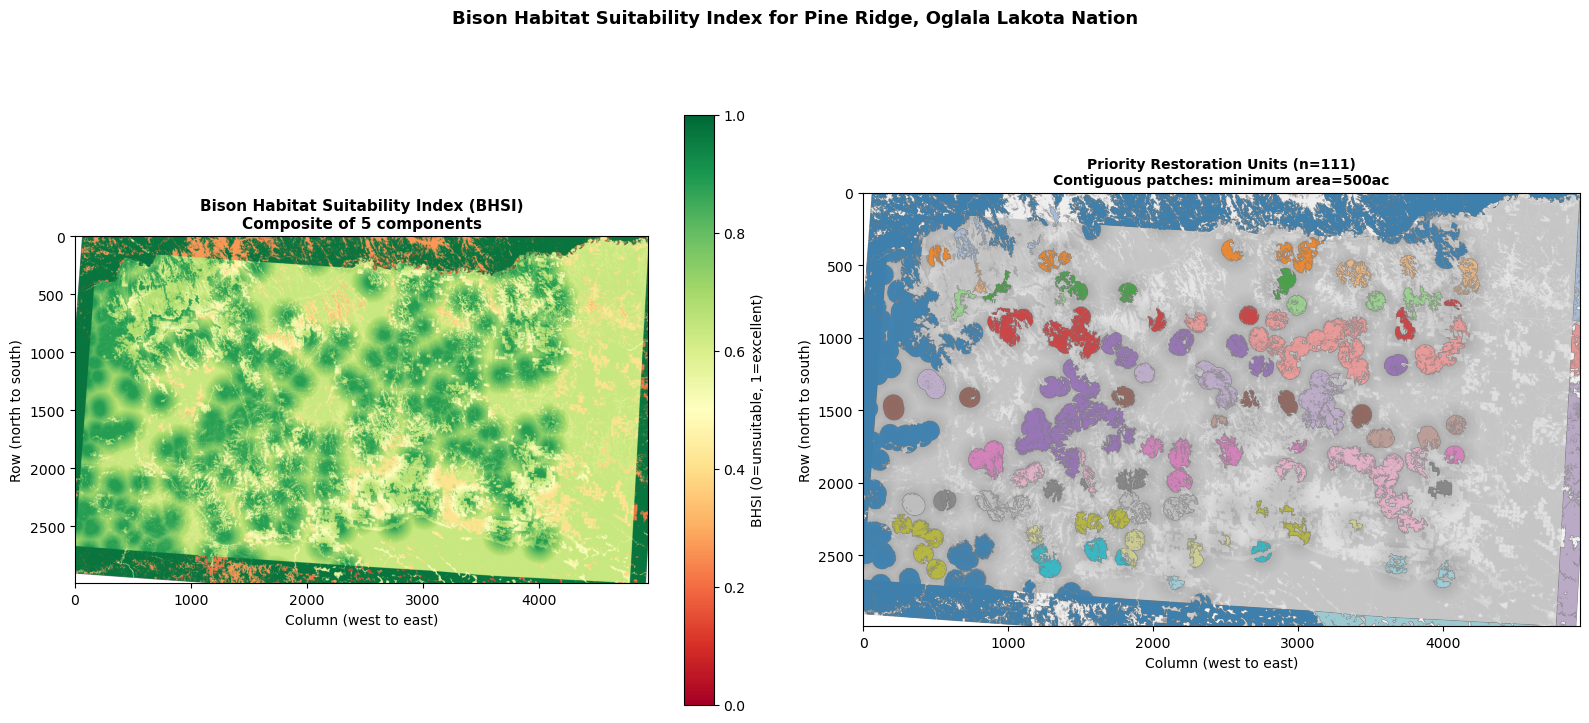

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# BHSI composite map
ax = axes[0]
im = ax.imshow(bhsi_array, cmap="RdYlGn", vmin=0, vmax=1, origin="upper")
plt.colorbar(im, ax=ax, label="BHSI (0=unsuitable, 1=excellent)", shrink=0.8)
ax.set_title(
    "Bison Habitat Suitability Index (BHSI)\n"
    "Composite of 5 components",
    fontsize=11, fontweight="bold",
)
ax.set_xlabel("Column (west to east)")
ax.set_ylabel("Row (north to south)")

# Priority patches map
ax = axes[1]
ax.imshow(bhsi_array, cmap="Greys", vmin=0, vmax=1, origin="upper", alpha=0.4)

# Draw patch labels once; avoid allocating a full RGBA raster per patch.
if n_patches > 0:
    patch_display = np.ma.masked_where(label_raster == 0, label_raster)
    ax.imshow(patch_display, cmap="tab20", origin="upper", alpha=0.75)

ax.set_title(
    f"Priority Restoration Units (n={n_patches})\n"
    f"Contiguous patches: minimum area={MIN_PATCH_ACRES:.0f}ac",
    fontsize=10, fontweight="bold",
)
ax.set_xlabel("Column (west to east)")
ax.set_ylabel("Row (north to south)")

plt.suptitle(
    "Bison Habitat Suitability Index for Pine Ridge, Oglala Lakota Nation",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
fig.savefig(FIGURES_DIR/"07_bhsi_composite.png", dpi=150, bbox_inches="tight")
plt.show()

## Component Contribution Summary

In [8]:
print("BHSI COMPONENT WEIGHTS AND MEAN SCORES")
print(f"  {'Component':<15} {'Weight':>8}  {'Mean Score':>12}  {'Contribution':>14}")

total_contribution = 0
for comp, weight in BHSI_WEIGHTS.items():
    path = LAYER_PATHS.get(comp)
    if path and path.exists():
        with rasterio.open(path) as src:
            arr = src.read(1)
        mean_score = float(np.nanmean(arr))
    else:
        mean_score = float("nan")
    contribution = weight * mean_score if not np.isnan(mean_score) else 0
    total_contribution += contribution
    print(f"  {comp:<15} {weight*100:>7.0f}%  {mean_score:>12.3f}  {contribution:>14.3f}")

print("  " + "-" * 54)
print(f"  {'BHSI Total':<15} {'100%':>8}  {'':>12}  {total_contribution:>14.3f}")
print()
print(f"Mean BHSI across Pine Ridge: {np.nanmean(bhsi_array):.3f}")
print()
print("INTERPRETATION:")
if np.nanmean(bhsi_array) >= 0.6:
    print("  HIGH: Substantial portion of Pine Ridge is suitable or restorable.")
elif np.nanmean(bhsi_array) >= 0.4:
    print("  MODERATE: Significant habitat exists with restoration investment needed.")
else:
    print("  LOW: Most land requires restoration: identify priority patches first.")

BHSI COMPONENT WEIGHTS AND MEAN SCORES
  Component         Weight    Mean Score    Contribution
  vegetation           30%         0.791           0.237
  soils                20%         0.500           0.100
  water                25%         0.480           0.120
  topography           15%         0.944           0.142
  climate              10%         0.956           0.096
  ------------------------------------------------------
  BHSI Total          100%                         0.694

Mean BHSI across Pine Ridge: 0.712

INTERPRETATION:
  HIGH: Substantial portion of Pine Ridge is suitable or restorable.


In [11]:
# Sensitivity: show how top-ranked patches change under different weights
scenarios = {
    "Default":          BHSI_WEIGHTS,
    "Water-critical":   {"vegetation":0.25,"soils":0.20,"water":0.35,"topography":0.10,"climate":0.10},
    "Vegetation-heavy": {"vegetation":0.40,"soils":0.20,"water":0.20,"topography":0.15,"climate":0.05},
    "Equal weights":    {"vegetation":0.20,"soils":0.20,"water":0.20,"topography":0.20,"climate":0.20},
}

print("SENSITIVITY ANALYSIS: Top 5 patches under different weight scenarios")

for scenario_name, weights in scenarios.items():
    alt_bhsi = combine_bhsi_layers(available, weights=weights)
    alt_threshold = np.nanpercentile(alt_bhsi, BHSI_THRESHOLD_PCT)
    alt_high = (alt_bhsi > alt_threshold) & (~np.isnan(alt_bhsi))
    if not alt_high.any():
        print(f"  {scenario_name}: no high-suitability pixels found")
        continue
    _, alt_n = label_habitat_patches(
        alt_high, pixel_area_acres=pixel_area_acres, minimum_acres=MIN_PATCH_ACRES
    )
    overlap = (alt_high & high_suit).sum() / (alt_high | high_suit).sum()
    print(f"  {scenario_name}: {alt_n} patches | high-suitability spatial overlap with default: {overlap:.1%}")

print()
print("Higher spatial overlap indicates a more robust high-suitability footprint.")

SENSITIVITY ANALYSIS: Top 5 patches under different weight scenarios
  Default: 111 patches | high-suitability spatial overlap with default: 100.0%
  Water-critical: 114 patches | high-suitability spatial overlap with default: 96.3%
  Vegetation-heavy: 108 patches | high-suitability spatial overlap with default: 98.3%
  Equal weights: 107 patches | high-suitability spatial overlap with default: 95.6%

Higher spatial overlap indicates a more robust high-suitability footprint.


In [12]:
# Final export confirmation
print("FINAL OUTPUTS")
outputs = [
    ("outputs/bhsi_composite.tif", "BHSI raster with pixel-level scores"),
    ("outputs/priority_restoration_units.gpkg", "Priority units GeoPackage for GIS"),
    ("outputs/priority_restoration_units.csv",  "Priority units ranked summary table"),
    ("outputs/figures/07_bhsi_composite.png",   "BHSI composite map"),
]
for fname, desc in outputs:
    path = REPO_ROOT / fname
    exists = "Y" if path.exists() else "X (not found)"
    print(f"  {exists}  {fname}")
    print(f"       {desc}")

print()
print("NEXT STEPS:")
print("  1. Review priority_restoration_units.gpkg in GIS")
print("  2. Ground-truth top 5 patches with field observation")
print("  3. Overlay with land ownership and existing infrastructure")
print("  4. Confirm MIN_PATCH_ACRES threshold with bison program")
print("  5. Adjust BHSI weights in src/constants.py based on local knowledge")
print()
print("All results should be reviewed by OLC and the Oglala Lakota Nation")
print("land management offices before external distribution.")
print()
print(generate_citations(["census_aiannh","modis_ndvi","nlcd","gssurgo","dem_3dep","nhd","maca_climate"]))

FINAL OUTPUTS
  Y  outputs/bhsi_composite.tif
       BHSI raster with pixel-level scores
  Y  outputs/priority_restoration_units.gpkg
       Priority units GeoPackage for GIS
  Y  outputs/priority_restoration_units.csv
       Priority units ranked summary table
  Y  outputs/figures/07_bhsi_composite.png
       BHSI composite map

NEXT STEPS:
  1. Review priority_restoration_units.gpkg in GIS
  2. Ground-truth top 5 patches with field observation
  3. Overlay with land ownership and existing infrastructure
  4. Confirm MIN_PATCH_ACRES threshold with bison program
  5. Adjust BHSI weights in src/constants.py based on local knowledge

All results should be reviewed by OLC and the Oglala Lakota Nation
land management offices before external distribution.

DATA CITATIONS

US Census Bureau TIGER/Line AIANNH Boundaries
  https://www.census.gov/cgi-bin/geo/shapefiles/index.php
  Steward: US Census Bureau | License: Public domain

MODIS MOD13Q1 V061 NDVI via ORNL DAAC
  Didan, K. (2021). MODIS/